# N1 · domain randomization 弥合 sim2real gap (GPU-free)

> 配套 11.6-L1/L3 · GPU-free 玩具坐实 DR: 随机化的「环境参数」= 目标分布。
> **窄区域 (sim) 训** vs **全区域 (DR) 训**, 都在**真实全区域**评估。
> 看 DR 怎么把覆盖不足的 gap 补上 (覆盖→泛化, 同 M11.4)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import domain_rand as dr
import toy_env as env   # M11.1 共享
import numpy as np, torch
print('环境 = M11.1 2D 到达; 域随机化作用在目标分布 (narrow=sim, wide=real/DR)')

环境 = M11.1 2D 到达; 域随机化作用在目标分布 (narrow=sim, wide=real/DR)


## 1. 训两个策略: 无 DR (窄 sim) vs DR (全区域)

In [2]:
torch.manual_seed(0)
# 无 DR: 只在窄区域 (右上小块) 采专家 demo 训练
S0, A0 = dr.collect_demos(n=400, region='narrow', seed=0)
m0 = dr.build_policy(seed=0); dr.train_policy(m0, S0, A0)
# DR: 随机化目标到全区域采 demo 训练
Sd, Ad = dr.collect_demos(n=400, region='wide', seed=0)
md_ = dr.build_policy(seed=0); dr.train_policy(md_, Sd, Ad)
print('两个策略训练完毕 (无DR=窄区域目标, DR=全区域目标)')

两个策略训练完毕 (无DR=窄区域目标, DR=全区域目标)


## 2. sim2real gap: 在 sim(窄) 和 real(全) 上分别评估

无 DR (窄sim训)    : sim(窄) 1.00  real(全) 0.71
DR (全区域训)       : sim(窄) 1.00  real(全) 0.99


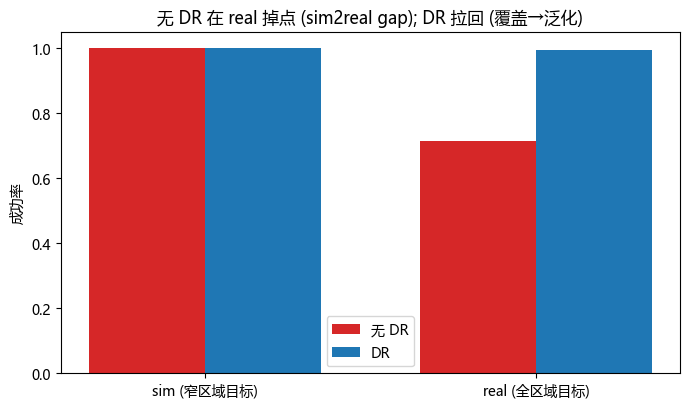

→ 无 DR: sim 好但 real 掉 (没见过的远目标失败); DR: 训练覆盖全配置 → real 泛化。


In [3]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
res = {
 '无 DR (窄sim训)': (dr.eval_region(m0,'narrow'), dr.eval_region(m0,'wide')),
 'DR (全区域训)':   (dr.eval_region(md_,'narrow'), dr.eval_region(md_,'wide')),
}
for k,(sim,real) in res.items():
    print(f'{k:16}: sim(窄) {sim:.2f}  real(全) {real:.2f}')
x=np.arange(2); w=0.35
fig,ax=plt.subplots(figsize=(7,4.2))
ax.bar(x-w/2, [res['无 DR (窄sim训)'][0], res['无 DR (窄sim训)'][1]], w, label='无 DR', color='C3')
ax.bar(x+w/2, [res['DR (全区域训)'][0], res['DR (全区域训)'][1]], w, label='DR', color='C0')
ax.set_xticks(x); ax.set_xticklabels(['sim (窄区域目标)','real (全区域目标)']); ax.set_ylabel('成功率'); ax.set_ylim(0,1.05); ax.legend()
ax.set_title('无 DR 在 real 掉点 (sim2real gap); DR 拉回 (覆盖→泛化)')
plt.tight_layout(); plt.show()
print('→ 无 DR: sim 好但 real 掉 (没见过的远目标失败); DR: 训练覆盖全配置 → real 泛化。')

## 3. 看 gap 在哪: 无 DR 在哪些目标失败

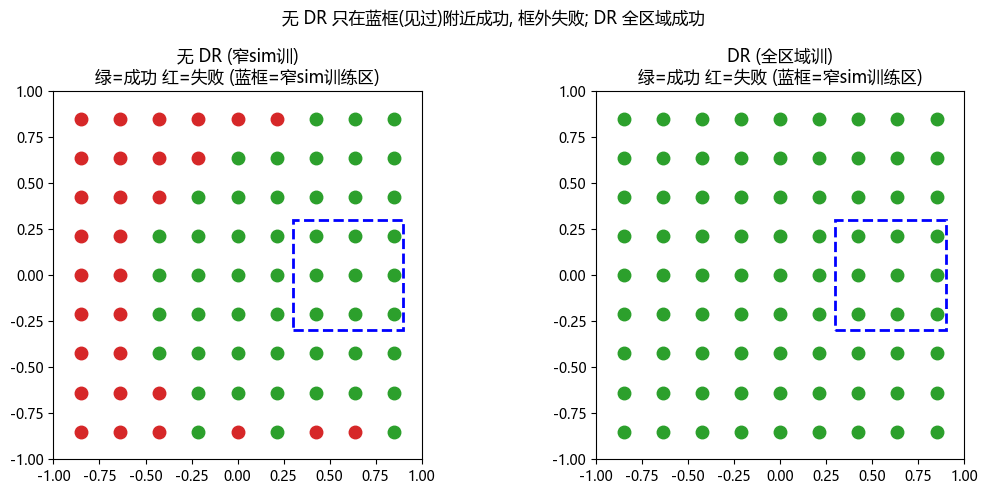

→ gap 的真相: 无 DR 只在训练覆盖的配置(蓝框)可靠, 框外=没见过=失败。DR 扩覆盖→处处成功。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
fig, axes = plt.subplots(1,2,figsize=(11,5))
for ax,(name,model) in zip(axes, [('无 DR (窄sim训)', m0), ('DR (全区域训)', md_)]):
    # 在全区域网格目标上测成功与否
    for gx in np.linspace(-0.85,0.85,9):
        for gy in np.linspace(-0.85,0.85,9):
            rng=np.random.default_rng(int((gx+1)*1000+(gy+1)*7))
            s=np.array([rng.uniform(-0.8,0.8),rng.uniform(-0.8,0.8),gx,gy],np.float32)
            ok=False
            for _ in range(env.MAX_T):
                a=model(torch.tensor(s[None],dtype=torch.float32)).detach().numpy()[0]
                s=env.step(s,a)
                if env.is_success(s): ok=True; break
            ax.plot(gx,gy,'o',color=('C2' if ok else 'C3'),ms=9)
    # 标出窄 sim 训练区域
    import matplotlib.patches as mp
    ax.add_patch(mp.Rectangle((0.3,-0.3),0.6,0.6,fill=False,ec='blue',lw=2,ls='--'))
    ax.set_title(f'{name}\n绿=成功 红=失败 (蓝框=窄sim训练区)'); ax.set_aspect('equal'); ax.set_xlim(-1,1); ax.set_ylim(-1,1)
plt.suptitle('无 DR 只在蓝框(见过)附近成功, 框外失败; DR 全区域成功'); plt.tight_layout(); plt.show()
print('→ gap 的真相: 无 DR 只在训练覆盖的配置(蓝框)可靠, 框外=没见过=失败。DR 扩覆盖→处处成功。')

## 4. 反思
你实测了 DR 弥合 sim2real gap。带走:
- **sim2real gap = 覆盖不足**: 窄 sim 训的策略只在见过的配置可靠, real 的新配置失败 (同 M11.4 分布漂移)。
- **DR = 用覆盖换泛化**: 训练随机化到覆盖真实 → real 不再"没见过" → 泛化。
- 真实 IsaacLab 里随机化的是摩擦/光照/传感器噪声等; 机制一样 (覆盖→泛化)。
下一步 N2: 真 IsaacLab 怎么跑 (需 NV GPU, 复用你 AntBot 经验)。